# Importance Demo

This notebook builds a synthetic two-class graph dataset to show how `ImportanceNSPPK` highlights class-relevant nodes.

Each graph is composed of:
1. a class-specific core subgraph shared by all graphs in that class
2. a random noise subgraph unique to each graph
3. a fixed number of random edges connecting core and noise

The full graph is kept exactly degree-3. Because of that constraint, the requested component sizes must have the same parity as the number of connecting edges. With the requested defaults `core_size=5`, `noise_size=15`, and `num_connecting_edges=2`, the nearest feasible sizes are `6` and `16`.

In [1]:
from pathlib import Path
import sys
import math
import random

REPO_CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next(candidate for candidate in REPO_CANDIDATES if (candidate / 'src').exists())
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

from importance_nsppk import ImportanceNSPPK
from nsppk import NodeNSPPK


## Configure the synthetic dataset

You can change the requested sizes below. This demo automatically promotes each size to the nearest feasible one when needed so the final combined graph stays 3-regular.

In [2]:
REQUESTED_CORE_SIZE = 5  # Desired number of nodes in the class-specific core subgraph before feasibility adjustment.
REQUESTED_NOISE_SIZE = 15  # Desired number of nodes in the random noise subgraph before feasibility adjustment.
NUM_CONNECTING_EDGES = 2  # Number of random edges used to connect the core subgraph to the noise subgraph.
NODE_ALPHABET_SIZE = 4  # Number of discrete node labels sampled uniformly when generating synthetic graphs.
EDGE_ALPHABET_SIZE = 2  # Number of discrete edge labels sampled uniformly when generating synthetic graphs.
GRAPHS_PER_CLASS = 32  # Number of graphs generated for each class; total dataset size is twice this value.
NUM_EXAMPLE_GRAPHS = 8*2  # Number of graphs to display in the visualization cells.
DATASET_SEED = 7  # Master random seed controlling reproducible graph generation.

RADIUS = 1  # NSPPK radius hyperparameter controlling rooted neighborhood size.
DISTANCE = 4  # NSPPK distance hyperparameter controlling how far paired neighborhoods can be.
CONNECTOR = 1  # NSPPK connector hyperparameter controlling whether connector paths are included.
NBITS = 12  # Feature hashing dimension parameter; the feature space size is 2**NBITS.

IMPORTANCE_KEY = 'importance'  # Node and edge attribute name used to store learned importance scores.
N_ITER = 3  # Number of repeated train/test splits used to stabilize feature importance estimates.
N_ESTIMATORS = 300  # Number of trees in each ExtraTreesClassifier used inside ImportanceNSPPK.
QUANTILE = 0.7  # Quantile threshold used to zero out low-importance NSPPK features.


def promote_size_to_feasible(size, num_connecting_edges):
    if size <= num_connecting_edges:
        raise ValueError('Each component must have more nodes than connector edges.')
    if size < 4:
        raise ValueError('Each component must have at least 4 nodes.')
    if num_connecting_edges < 1:
        raise ValueError('num_connecting_edges must be positive.')
    if num_connecting_edges % 2 != 0:
        raise ValueError(
            'This notebook keeps graphs exactly 3-regular by giving each component '
            'num_connecting_edges attachment nodes of degree 2, so num_connecting_edges must be even.'
        )
    if size % 2 != num_connecting_edges % 2:
        size += 1
    return size


CORE_SIZE = promote_size_to_feasible(REQUESTED_CORE_SIZE, NUM_CONNECTING_EDGES)  # Feasible core size after enforcing the exact degree-3 construction constraints.
NOISE_SIZE = promote_size_to_feasible(REQUESTED_NOISE_SIZE, NUM_CONNECTING_EDGES)  # Feasible noise size after enforcing the exact degree-3 construction constraints.

print(f'Requested core size: {REQUESTED_CORE_SIZE} -> actual core size: {CORE_SIZE}')
print(f'Requested noise size: {REQUESTED_NOISE_SIZE} -> actual noise size: {NOISE_SIZE}')
print(f'Connecting edges per graph: {NUM_CONNECTING_EDGES}')


Requested core size: 5 -> actual core size: 6
Requested noise size: 15 -> actual noise size: 16
Connecting edges per graph: 2


## Helper functions

The component generator builds a simple graph where exactly `num_connecting_edges` nodes have degree 2 and all other nodes have degree 3. Those degree-2 nodes act as attachment points; once we connect core and noise, every node ends up with degree 3 in the final graph.

In [3]:
def make_attachment_component(
    num_nodes,
    num_connecting_edges,
    node_alphabet_size=3,
    edge_alphabet_size=3,
    seed=0,
):
    num_nodes = promote_size_to_feasible(num_nodes, num_connecting_edges)
    degree_sequence = [2] * num_connecting_edges + [3] * (num_nodes - num_connecting_edges)
    graph = nx.random_degree_sequence_graph(degree_sequence, seed=seed, tries=200)
    graph = nx.convert_node_labels_to_integers(graph)

    rng = random.Random(seed)
    shuffled_nodes = list(graph.nodes())
    rng.shuffle(shuffled_nodes)
    graph = nx.relabel_nodes(graph, {node: idx for idx, node in enumerate(shuffled_nodes)})

    attachment_nodes = sorted(node for node, degree in graph.degree() if degree == 2)
    if len(attachment_nodes) != num_connecting_edges:
        raise ValueError('Unexpected number of attachment nodes.')

    for node in graph.nodes():
        graph.nodes[node]['label'] = rng.randrange(node_alphabet_size)
        graph.nodes[node]['is_attachment'] = node in attachment_nodes

    for u, v in graph.edges():
        graph.edges[u, v]['label'] = rng.randrange(edge_alphabet_size)

    return graph


def combine_core_and_noise(core_graph, noise_graph, num_connecting_edges=2, edge_alphabet_size=3, seed=0):
    rng = random.Random(seed)
    graph = nx.disjoint_union(core_graph, noise_graph)

    core_size = core_graph.number_of_nodes()
    core_nodes = set(range(core_size))
    noise_nodes = set(range(core_size, graph.number_of_nodes()))

    core_attachment_nodes = [node for node in core_nodes if graph.nodes[node]['is_attachment']]
    noise_attachment_nodes = [node for node in noise_nodes if graph.nodes[node]['is_attachment']]

    rng.shuffle(core_attachment_nodes)
    rng.shuffle(noise_attachment_nodes)

    for core_node, noise_node in zip(core_attachment_nodes[:num_connecting_edges], noise_attachment_nodes[:num_connecting_edges]):
        graph.add_edge(core_node, noise_node, label=rng.randrange(edge_alphabet_size))

    for node in core_nodes:
        graph.nodes[node]['part'] = 'core'
        graph.nodes[node]['class_core'] = True

    for node in noise_nodes:
        graph.nodes[node]['part'] = 'noise'
        graph.nodes[node]['class_core'] = False

    graph.graph['core_nodes'] = sorted(core_nodes)
    graph.graph['noise_nodes'] = sorted(noise_nodes)
    graph.graph['num_connecting_edges'] = num_connecting_edges
    return graph


def make_two_class_dataset(
    requested_core_size=5,
    requested_noise_size=15,
    num_connecting_edges=2,
    graphs_per_class=24,
    node_alphabet_size=3,
    edge_alphabet_size=3,
    seed=0,
):
    core_size = promote_size_to_feasible(requested_core_size, num_connecting_edges)
    noise_size = promote_size_to_feasible(requested_noise_size, num_connecting_edges)

    core_graphs = [
        make_attachment_component(core_size, num_connecting_edges, node_alphabet_size, edge_alphabet_size, seed=seed),
        make_attachment_component(core_size, num_connecting_edges, node_alphabet_size, edge_alphabet_size, seed=seed + 1),
    ]

    graphs = []
    targets = []

    for class_id, core_graph in enumerate(core_graphs):
        for graph_idx in range(graphs_per_class):
            noise_seed = seed + 1000 + class_id * graphs_per_class + graph_idx
            connect_seed = seed + 2000 + class_id * graphs_per_class + graph_idx
            noise_graph = make_attachment_component(
                noise_size,
                num_connecting_edges,
                node_alphabet_size=node_alphabet_size,
                edge_alphabet_size=edge_alphabet_size,
                seed=noise_seed,
            )
            graph = combine_core_and_noise(
                core_graph,
                noise_graph,
                num_connecting_edges=num_connecting_edges,
                edge_alphabet_size=edge_alphabet_size,
                seed=connect_seed,
            )
            graph.graph['class_id'] = class_id
            graphs.append(graph)
            targets.append(class_id)

    return core_graphs, graphs, np.asarray(targets)


def select_example_indices(graphs_per_class, num_example_graphs):
    num_example_graphs = max(2, int(num_example_graphs))
    class0_count = math.ceil(num_example_graphs / 2)
    class1_count = max(1, num_example_graphs - class0_count)

    class0_indices = np.linspace(0, graphs_per_class - 1, num=class0_count, dtype=int).tolist()
    class1_offsets = np.linspace(0, graphs_per_class - 1, num=class1_count, dtype=int).tolist()
    class1_indices = [graphs_per_class + idx for idx in class1_offsets]
    return class0_indices + class1_indices


def graph_summary_dataframe(graphs):
    rows = []
    for graph_idx, graph in enumerate(graphs):
        rows.append(
            {
                'graph_idx': graph_idx,
                'class_id': graph.graph['class_id'],
                'n_nodes': graph.number_of_nodes(),
                'n_edges': graph.number_of_edges(),
                'degree_min': min(dict(graph.degree()).values()),
                'degree_max': max(dict(graph.degree()).values()),
                'core_nodes': len(graph.graph['core_nodes']),
                'noise_nodes': len(graph.graph['noise_nodes']),
            }
        )
    return pd.DataFrame(rows)


def node_importance_dataframe(graphs, importance_key='importance'):
    rows = []
    for graph_idx, graph in enumerate(graphs):
        for node, data in graph.nodes(data=True):
            rows.append(
                {
                    'graph_idx': graph_idx,
                    'class_id': graph.graph['class_id'],
                    'node': node,
                    'part': data['part'],
                    'importance': data.get(importance_key, 0.0),
                    'label': data['label'],
                }
            )
    return pd.DataFrame(rows)


In [4]:
def plot_graph_parts(graphs, titles=None, cols=4, size=4.5):
    if titles is None:
        titles = [None] * len(graphs)

    rows = math.ceil(len(graphs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows))
    axes = np.atleast_1d(axes).ravel()
    palette = plt.cm.Set2.colors

    for ax, graph, title in zip(axes, graphs, titles):
        pos = {node: graph.nodes[node].get('pos') for node in graph.nodes()}
        if not all(value is not None for value in pos.values()):
            pos = nx.kamada_kawai_layout(graph)

        labels = [graph.nodes[node].get('label', 0) for node in graph.nodes()]
        unique_labels = sorted(set(labels))
        color_map = {label: palette[idx % len(palette)] for idx, label in enumerate(unique_labels)}
        node_colors = [color_map[label] for label in labels]

        edge_colors = [
            '#e76f51' if graph.nodes[u].get('part') == 'core' and graph.nodes[v].get('part') == 'core' else '#7a7a7a'
            for u, v in graph.edges()
        ]

        nx.draw(
            graph,
            pos,
            ax=ax,
            node_color=node_colors,
            node_size=180,
            edge_color=edge_colors,
            edgecolors='#111111',
            width=1.6,
            linewidths=1.0,
            with_labels=True,
            font_size=8,
        )
        if title is not None:
            ax.set_title(title)
        ax.set_axis_off()

    for ax in axes[len(graphs):]:
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


## Build the dataset

The two classes differ only in the core subgraph template. Noise is regenerated independently for every graph.

In [5]:
core_graphs, graphs, targets = make_two_class_dataset(
    requested_core_size=REQUESTED_CORE_SIZE,
    requested_noise_size=REQUESTED_NOISE_SIZE,
    num_connecting_edges=NUM_CONNECTING_EDGES,
    graphs_per_class=GRAPHS_PER_CLASS,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    seed=DATASET_SEED,
)

summary_df = graph_summary_dataframe(graphs)
print(f'Number of graphs: {len(graphs)}')
print(f'Classes: {np.bincount(targets)}')
display(summary_df.groupby('class_id')[['n_nodes', 'n_edges', 'degree_min', 'degree_max']].agg(['mean', 'min', 'max']))


Number of graphs: 64
Classes: [32 32]


n_nodes         n_edges         degree_min         degree_max        
            mean min max    mean min max       mean min max       mean min max
class_id                                                                      
0           22.0  22  22    33.0  33  33        3.0   3   3        3.0   3   3
1           22.0  22  22    33.0  33  33        3.0   3   3        3.0   3   3

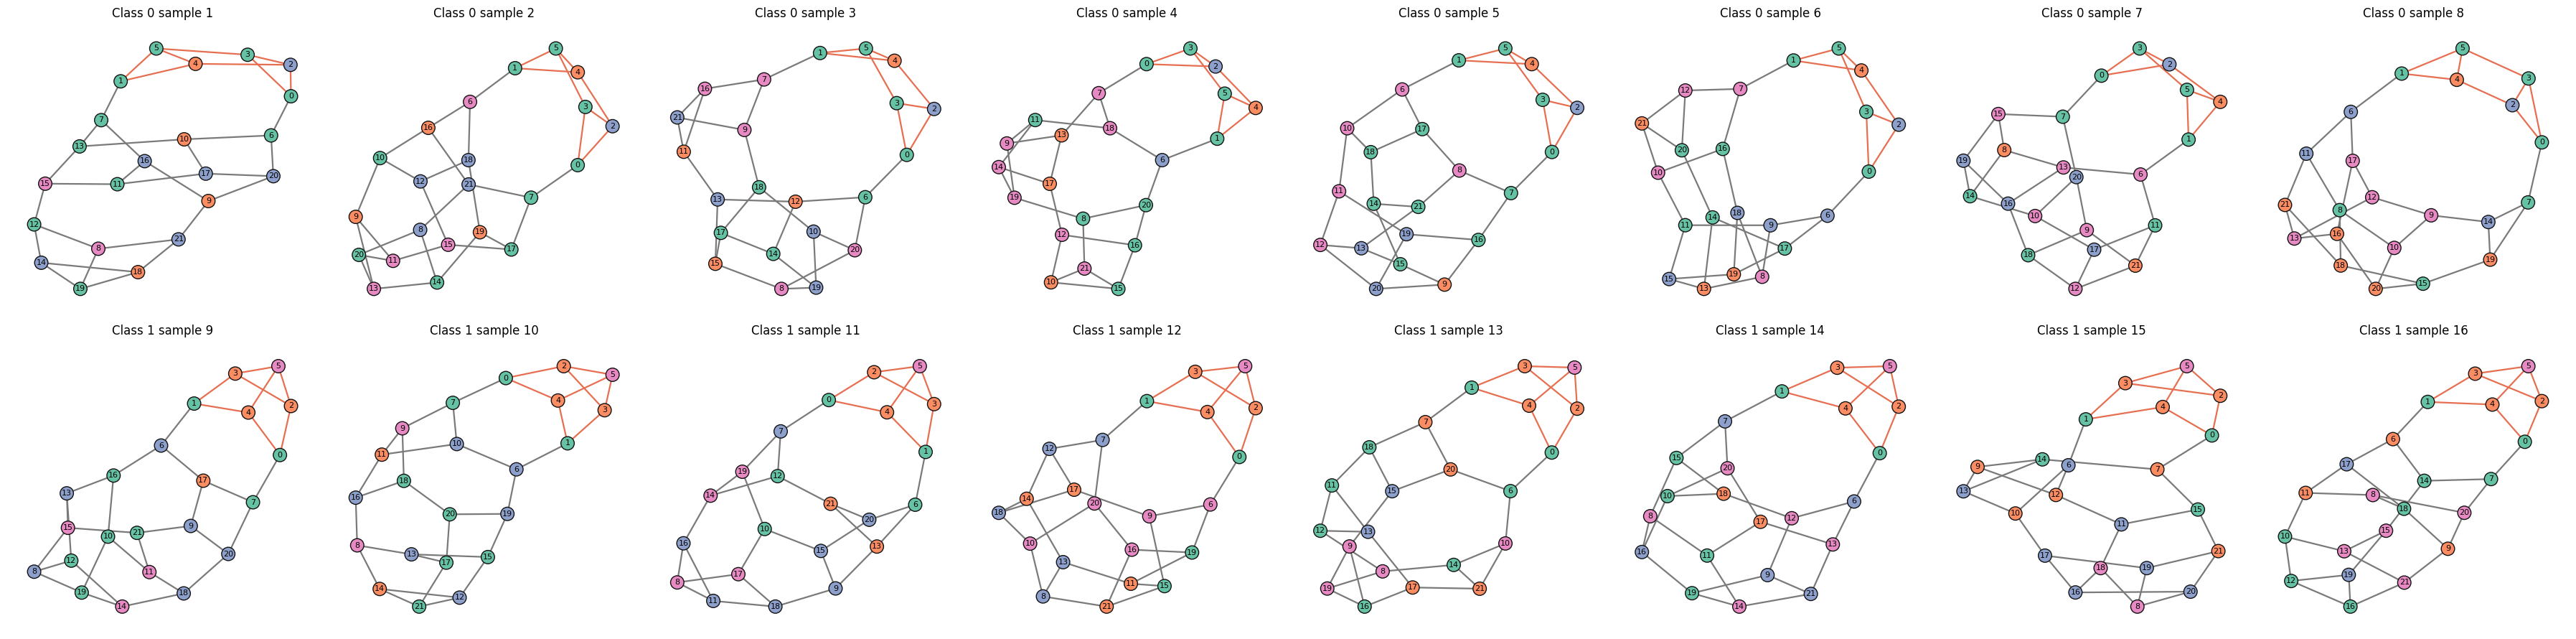

In [6]:
example_indices = select_example_indices(GRAPHS_PER_CLASS, NUM_EXAMPLE_GRAPHS)
sample_graphs = [graphs[idx] for idx in example_indices]
sample_titles = [f'Class {graphs[idx].graph["class_id"]} sample {i + 1}' for i, idx in enumerate(example_indices)]
plot_graph_parts(sample_graphs, titles=sample_titles, cols=min(8, NUM_EXAMPLE_GRAPHS), size=4.5)


## Fit `ImportanceNSPPK`

We first build node-level NSPPK features with `NodeNSPPK`, then train `ImportanceNSPPK` using the class labels. The transformed graphs carry a per-node importance score and a derived edge importance score.

In [7]:
node_encoder = NodeNSPPK(
    radius=RADIUS,
    distance=DISTANCE,
    connector=CONNECTOR,
    nbits=NBITS,
    dense=True,
    parallel=False,
)

importance_model = ImportanceNSPPK(
    node_nsppk=node_encoder,
    importance_key=IMPORTANCE_KEY,
    n_iter=N_ITER,
    n_estimators=N_ESTIMATORS,
    quantile=QUANTILE,
    parallel=False,
    normalize=True,
)

importance_model.fit(graphs, targets)
importance_graphs = importance_model.transform(graphs)

nonzero_features = int(np.count_nonzero(importance_model.feature_importance_vector))
print(f'Non-zero importance features: {nonzero_features} / {importance_model.feature_importance_vector.shape[0]}')


Non-zero importance features: 1092 / 4096


mean  median    std
class_id part                       
0        core   0.780   0.798  0.161
         noise  0.435   0.414  0.207
1        core   0.413   0.322  0.269
         noise  0.132   0.123  0.069

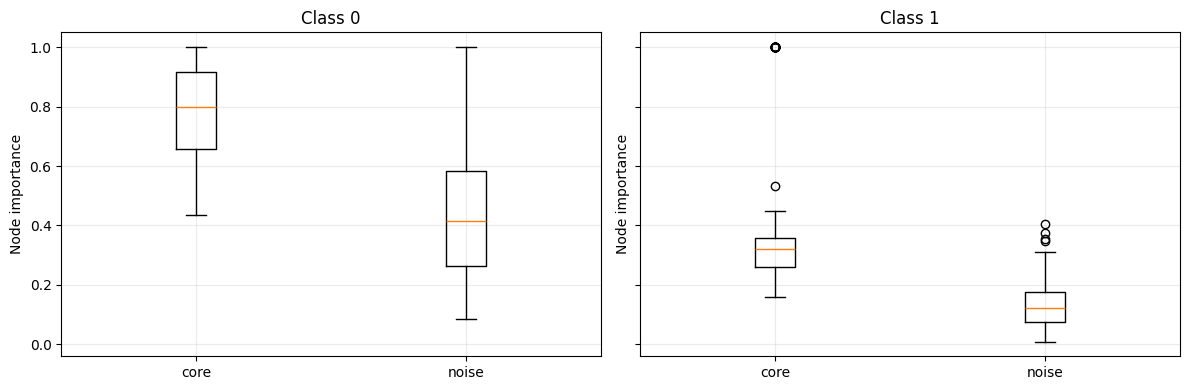

In [8]:
importance_df = node_importance_dataframe(importance_graphs, importance_key=IMPORTANCE_KEY)
importance_summary = importance_df.groupby(['class_id', 'part'])['importance'].agg(['mean', 'median', 'std']).round(3)
display(importance_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for class_id, ax in enumerate(axes):
    class_df = importance_df[importance_df['class_id'] == class_id]
    core_values = class_df[class_df['part'] == 'core']['importance'].to_numpy()
    noise_values = class_df[class_df['part'] == 'noise']['importance'].to_numpy()
    ax.boxplot([core_values, noise_values], tick_labels=['core', 'noise'])
    ax.set_title(f'Class {class_id}')
    ax.set_ylabel('Node importance')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Inspect the top important features

This cell builds the collision-aware feature archive, ranks the highest-importance hashed features, and visualizes one representative subgraph for each top feature.

,rank,feature_id,importance,occurrence_count,distinct_signature_count,source_graph_index
0,1,819,1.0000,172,60,1
1,2,1790,0.8393,184,59,1
2,3,2619,0.8117,104,57,0
3,4,58,0.6830,113,66,1
4,5,2818,0.6220,161,66,0
5,6,2683,0.4471,182,69,0
6,7,2063,0.4352,110,70,0
7,8,3331,0.4034,206,73,0
8,9,3530,0.3853,110,68,0
9,10,3038,0.3665,475,58,0


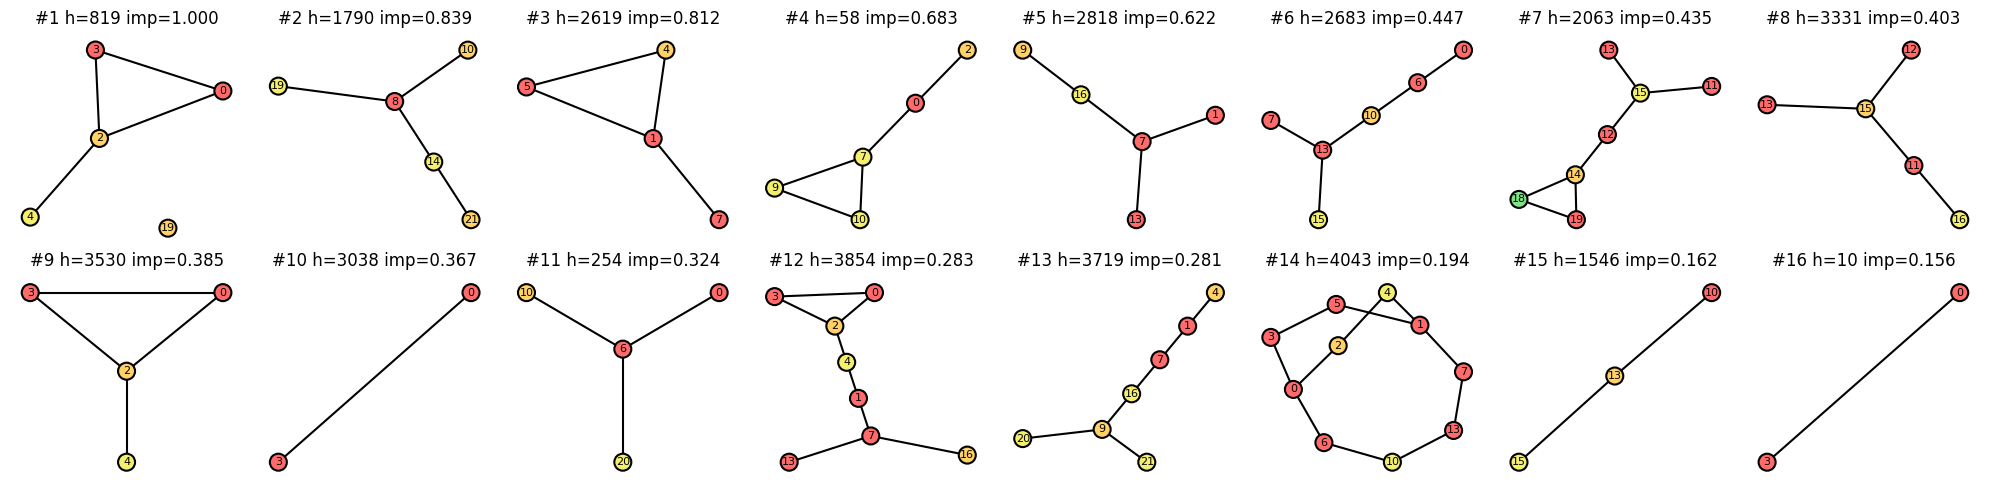

In [9]:
from utils import plot_graphs

TOP_K_FEATURES = min(8*2, NUM_EXAMPLE_GRAPHS)

importance_model.build_feature_archive(graphs)
top_features = importance_model.get_top_features(top_k=TOP_K_FEATURES)

top_features_df = pd.DataFrame(
    [
        {
            'rank': rank + 1,
            'feature_id': feature_info['feature_id'],
            'importance': round(feature_info['importance'], 4),
            'occurrence_count': feature_info['occurrence_count'],
            'distinct_signature_count': feature_info['distinct_signature_count'],
            'source_graph_index': feature_info['source_graph_index'],
        }
        for rank, feature_info in enumerate(top_features)
    ]
)
display(top_features_df)

top_feature_graphs = [feature_info['representative_graph'] for feature_info in top_features]
top_feature_titles = [
    f"#{rank + 1} h={feature_info['feature_id']} imp={feature_info['importance']:.3f}"
    for rank, feature_info in enumerate(top_features)
]

plot_graphs(
    top_feature_graphs,
    titles=top_feature_titles,
    num_graphs_per_row=min(8, TOP_K_FEATURES),
    node_color_key='label',
    size=2.5,
    use_pos=False,
)


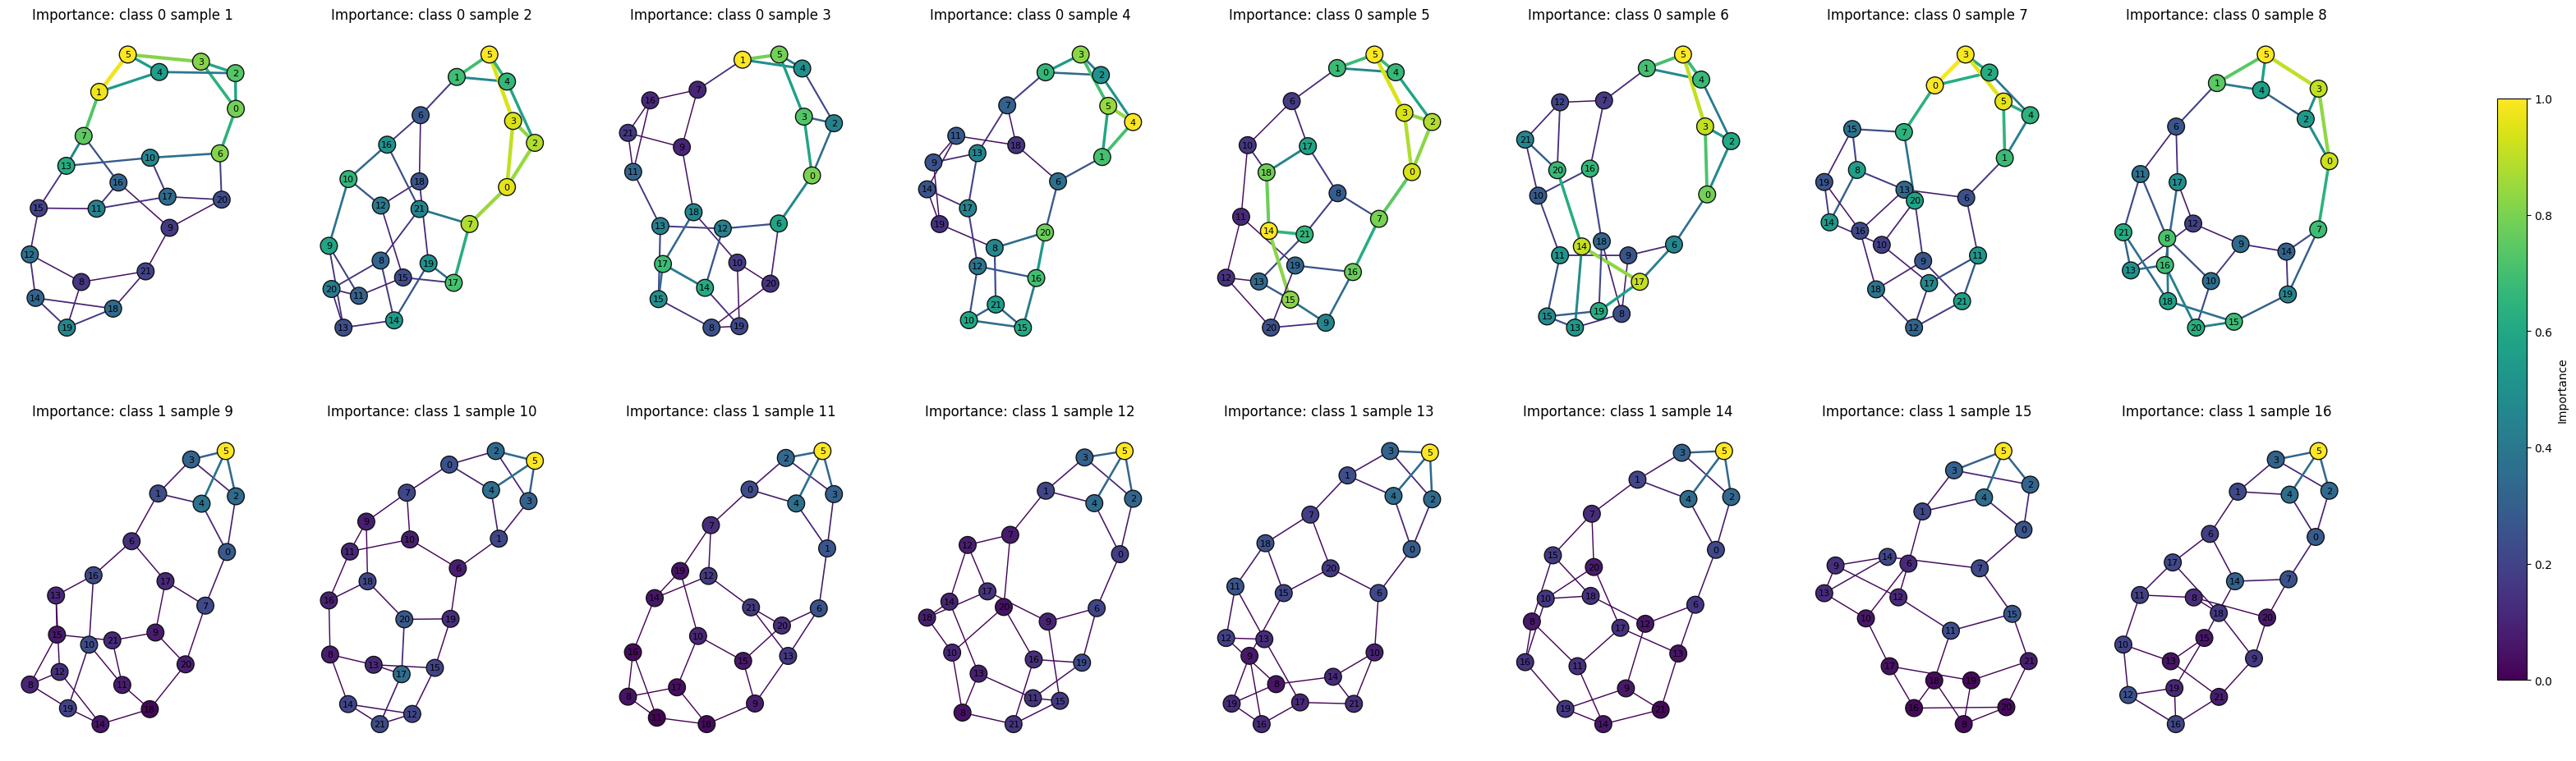

In [10]:
from utils import plot_graph_importance

importance_samples = [importance_graphs[idx] for idx in example_indices]
importance_titles = [f'Importance: class {importance_graphs[idx].graph["class_id"]} sample {i + 1}' for i, idx in enumerate(example_indices)]
plot_graph_importance(
    importance_samples,
    titles=importance_titles,
    importance_key=IMPORTANCE_KEY,
    cols=min(8, NUM_EXAMPLE_GRAPHS),
    size=5.75,
    use_pos=False,
)
